In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.datasets import fetch_california_housing


In [2]:
# Load California Housing dataset
data = fetch_california_housing()

# Convert data into DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

# Add target column
df['MedHouseVal'] = data.target

# Display first 5 rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
df.shape

(20640, 9)

In [8]:
# Select the two required input features
X = df[['MedInc','HouseAge']].values
# Target variable
Y = df['MedHouseVal'].values.reshape(-1,1)
print('X shape:',X.shape)
print('Y shape:',Y.shape)


X shape: (20640, 2)
Y shape: (20640, 1)


In [9]:
# Set random seed for reproducibility
np.random.seed(42)

# Number of samples
n_samples = X.shape[0]

# Generate shuffled indices
indices = np.random.permutation(n_samples)

# Calculate split point
split = int(0.8 * n_samples)

# Training and testing indices
train_indices = indices[:split]
test_indices = indices[split:]

# Create training and testing data
X_train = X[train_indices]
X_test = X[test_indices]

y_train = y[train_indices]
y_test = y[test_indices]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (16512, 2)
X_test : (4128, 2)
y_train: (16512, 1)
y_test : (4128, 1)


In [11]:
# Calculate mean and standard deviation from training data
X_mean = np.mean(X_train, axis=0)
X_std = np.std(X_train, axis=0)

# Normalize training data
X_train = (X_train - X_mean) / X_std

# Normalize test data using training mean and std
X_test = (X_test - X_mean) / X_std

print("Training mean:", X_mean)
print("Training std :", X_std)

print("\nFirst 5 normalized training samples:")
print(X_train[:5])

Training mean: [-9.81836846e-15 -6.79904023e-17]
Training std : [1. 1.]

First 5 normalized training samples:
[[-1.15453971 -0.29052552]
 [-0.7062249   0.10661646]
 [-0.20585896  1.85404119]
 [ 0.98467237 -0.9259527 ]
 [-0.07670674  0.42433005]]


In [12]:
def relu(x):
    return np.maximum(0, x)

In [13]:
x_test_relu = np.array([-3, -1, 0, 2, 5])

print(relu(x_test_relu))

[0 0 0 2 5]


In [14]:
def relu_derivative(x):
    return (x > 0).astype(float)

In [15]:
print(relu_derivative(x_test_relu))

[0. 0. 0. 1. 1.]


In [16]:
def initialize_parameters():

    # Input layer → Hidden layer 1
    W1 = np.random.randn(2, 5) * 0.01
    b1 = np.zeros((1, 5))

    # Hidden layer 1 → Hidden layer 2
    W2 = np.random.randn(5, 3) * 0.01
    b2 = np.zeros((1, 3))

    # Hidden layer 2 → Output layer
    W3 = np.random.randn(3, 1) * 0.01
    b3 = np.zeros((1, 1))

    return W1, b1, W2, b2, W3, b3

In [17]:
W1, b1, W2, b2, W3, b3 = initialize_parameters()

print("W1:", W1.shape)
print("b1:", b1.shape)

print("W2:", W2.shape)
print("b2:", b2.shape)

print("W3:", W3.shape)
print("b3:", b3.shape)

W1: (2, 5)
b1: (1, 5)
W2: (5, 3)
b2: (1, 3)
W3: (3, 1)
b3: (1, 1)


In [18]:
def forward_pass(X, W1, b1, W2, b2, W3, b3):

    # First hidden layer
    Z1 = X @ W1 + b1
    A1 = relu(Z1)

    # Second hidden layer
    Z2 = A1 @ W2 + b2
    A2 = relu(Z2)

    # Output layer
    Z3 = A2 @ W3 + b3

    # Linear output
    y_pred = Z3

    return y_pred, Z1, A1, Z2, A2

In [19]:
y_pred, Z1, A1, Z2, A2 = forward_pass(
    X_train, W1, b1, W2, b2, W3, b3
)

print("Prediction shape:", y_pred.shape)
print("Z1 shape:", Z1.shape)
print("A1 shape:", A1.shape)
print("Z2 shape:", Z2.shape)
print("A2 shape:", A2.shape)

Prediction shape: (16512, 1)
Z1 shape: (16512, 5)
A1 shape: (16512, 5)
Z2 shape: (16512, 3)
A2 shape: (16512, 3)


In [21]:
def mse_loss(y_true, y_pred):
    return np.mean((y_pred - y_true) ** 2)

In [22]:
loss = mse_loss(y_train, y_pred)

print("Initial MSE:", loss)

Initial MSE: 5.603460501425554


In [23]:
def backward_pass(X, y, y_pred, Z1, A1, Z2, A2, W2, W3):

    # Number of training samples
    n = X.shape[0]

    # -----------------------------
    # Output layer
    # -----------------------------

    dZ3 = (2 / n) * (y_pred - y)

    dW3 = A2.T @ dZ3
    db3 = np.sum(dZ3, axis=0, keepdims=True)


    # -----------------------------
    # Second hidden layer
    # -----------------------------

    dA2 = dZ3 @ W3.T

    dZ2 = dA2 * relu_derivative(Z2)

    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)


    # -----------------------------
    # First hidden layer
    # -----------------------------

    dA1 = dZ2 @ W2.T

    dZ1 = dA1 * relu_derivative(Z1)

    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)


    return dW1, db1, dW2, db2, dW3, db3

In [24]:
def backward_pass(X, y, y_pred, Z1, A1, Z2, A2, W2, W3):

    # Number of training samples
    n = X.shape[0]

    # -----------------------------
    # Output layer
    # -----------------------------

    dZ3 = (2 / n) * (y_pred - y)

    dW3 = A2.T @ dZ3
    db3 = np.sum(dZ3, axis=0, keepdims=True)


    # -----------------------------
    # Second hidden layer
    # -----------------------------

    dA2 = dZ3 @ W3.T

    dZ2 = dA2 * relu_derivative(Z2)

    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)


    # -----------------------------
    # First hidden layer
    # -----------------------------

    dA1 = dZ2 @ W2.T

    dZ1 = dA1 * relu_derivative(Z1)

    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)


    return dW1, db1, dW2, db2, dW3, db3

In [25]:
def train_gradient_descent(X, y, learning_rate=0.01, epochs=1000):

    # Initialize parameters
    W1, b1, W2, b2, W3, b3 = initialize_parameters()

    # Store loss
    losses = []

    # Start timer
    start_time = time.time()

    for epoch in range(epochs):

        # -------------------------
        # Forward propagation
        # -------------------------

        y_pred, Z1, A1, Z2, A2 = forward_pass(
            X, W1, b1, W2, b2, W3, b3
        )

        # -------------------------
        # Calculate loss
        # -------------------------

        loss = mse_loss(y, y_pred)
        losses.append(loss)

        # -------------------------
        # Backpropagation
        # -------------------------

        dW1, db1, dW2, db2, dW3, db3 = backward_pass(
            X, y, y_pred,
            Z1, A1, Z2, A2,
            W2, W3
        )

        # -------------------------
        # Gradient descent update
        # -------------------------

        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1

        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2

        W3 -= learning_rate * dW3
        b3 -= learning_rate * db3

    # Total training time
    training_time = time.time() - start_time

    # Return everything needed later
    parameters = (W1, b1, W2, b2, W3, b3)

    return parameters, losses, training_time

In [26]:
gd_params_001, gd_losses_001, gd_time_001 = train_gradient_descent(
    X_train,
    y_train,
    learning_rate=0.01,
    epochs=1000
)

print("Training time:", gd_time_001)
print("Final training MSE:", gd_losses_001[-1])

Training time: 2.5311150550842285
Final training MSE: 1.3279422668199001


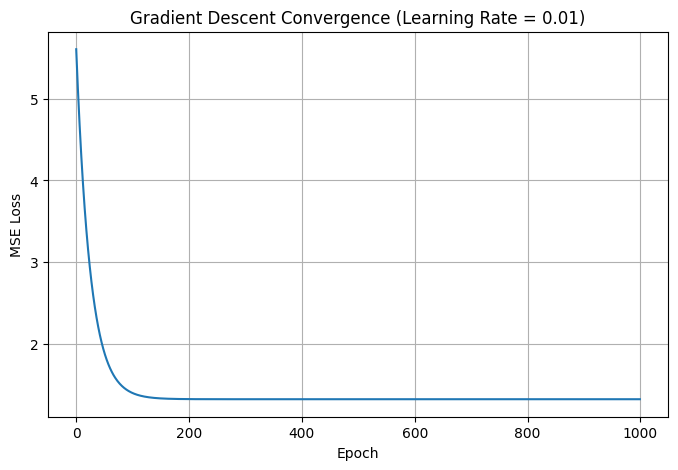

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(gd_losses_001)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Gradient Descent Convergence (Learning Rate = 0.01)")

plt.grid()
plt.show()

In [28]:
gd_params_0001, gd_losses_0001, gd_time_0001 = train_gradient_descent(
    X_train,
    y_train,
    learning_rate=0.001,
    epochs=1000
)

print("Training time:", gd_time_0001)
print("Final training MSE:", gd_losses_0001[-1])

Training time: 2.8943541049957275
Final training MSE: 1.4061528656176094


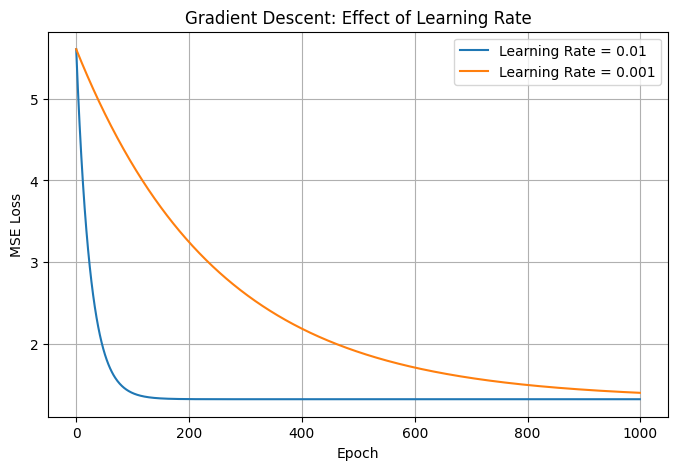

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(gd_losses_001, label="Learning Rate = 0.01")
plt.plot(gd_losses_0001, label="Learning Rate = 0.001")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Gradient Descent: Effect of Learning Rate")

plt.legend()
plt.grid()
plt.show()

In [30]:
def train_momentum(X, y, learning_rate=0.01, beta=0.9, epochs=1000):

    # Initialize network parameters
    W1, b1, W2, b2, W3, b3 = initialize_parameters()

    # Initialize velocity for all parameters
    vW1 = np.zeros_like(W1)
    vb1 = np.zeros_like(b1)

    vW2 = np.zeros_like(W2)
    vb2 = np.zeros_like(b2)

    vW3 = np.zeros_like(W3)
    vb3 = np.zeros_like(b3)

    # Store loss at every epoch
    losses = []

    # Start timer
    start_time = time.time()

    for epoch in range(epochs):

        # -------------------------
        # Forward propagation
        # -------------------------

        y_pred, Z1, A1, Z2, A2 = forward_pass(
            X, W1, b1, W2, b2, W3, b3
        )

        # -------------------------
        # Calculate loss
        # -------------------------

        loss = mse_loss(y, y_pred)
        losses.append(loss)

        # -------------------------
        # Backpropagation
        # -------------------------

        dW1, db1, dW2, db2, dW3, db3 = backward_pass(
            X, y, y_pred,
            Z1, A1, Z2, A2,
            W2, W3
        )

        # -------------------------
        # Update velocities
        # -------------------------

        vW1 = beta * vW1 + (1 - beta) * dW1
        vb1 = beta * vb1 + (1 - beta) * db1

        vW2 = beta * vW2 + (1 - beta) * dW2
        vb2 = beta * vb2 + (1 - beta) * db2

        vW3 = beta * vW3 + (1 - beta) * dW3
        vb3 = beta * vb3 + (1 - beta) * db3

        # -------------------------
        # Update parameters
        # -------------------------

        W1 -= learning_rate * vW1
        b1 -= learning_rate * vb1

        W2 -= learning_rate * vW2
        b2 -= learning_rate * vb2

        W3 -= learning_rate * vW3
        b3 -= learning_rate * vb3

    # Calculate training time
    training_time = time.time() - start_time

    # Store final parameters
    parameters = (W1, b1, W2, b2, W3, b3)

    return parameters, losses, training_time

In [31]:
momentum_params_001, momentum_losses_001, momentum_time_001 = train_momentum(
    X_train,
    y_train,
    learning_rate=0.01,
    beta=0.9,
    epochs=1000
)

print("Training time:", momentum_time_001)
print("Final training MSE:", momentum_losses_001[-1])

Training time: 3.4216411113739014
Final training MSE: 1.3279366841707274


In [32]:
momentum_params_0001, momentum_losses_0001, momentum_time_0001 = train_momentum(
    X_train,
    y_train,
    learning_rate=0.001,
    beta=0.9,
    epochs=1000
)

print("Training time:", momentum_time_0001)
print("Final training MSE:", momentum_losses_0001[-1])

Training time: 4.493144989013672
Final training MSE: 1.4029528927372905


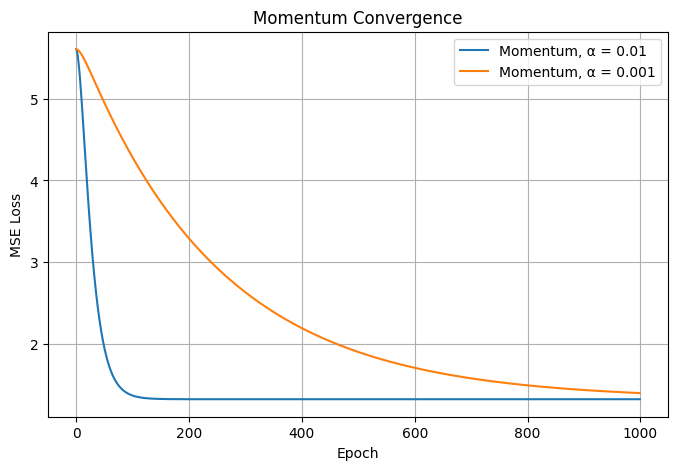

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(
    momentum_losses_001,
    label="Momentum, α = 0.01"
)

plt.plot(
    momentum_losses_0001,
    label="Momentum, α = 0.001"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Momentum Convergence")

plt.legend()
plt.grid()
plt.show()

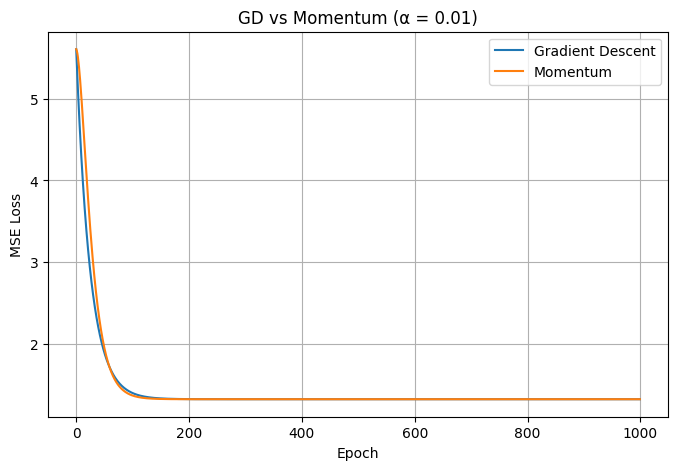

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(
    gd_losses_001,
    label="Gradient Descent"
)

plt.plot(
    momentum_losses_001,
    label="Momentum"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("GD vs Momentum (α = 0.01)")

plt.legend()
plt.grid()
plt.show()

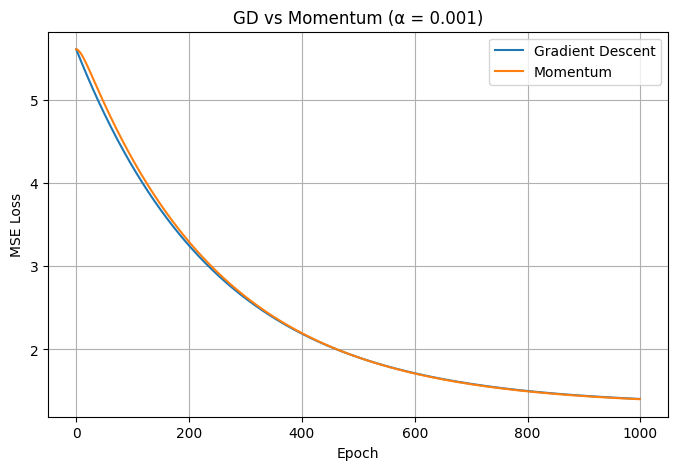

In [35]:
plt.figure(figsize=(8, 5))

plt.plot(
    gd_losses_0001,
    label="Gradient Descent"
)

plt.plot(
    momentum_losses_0001,
    label="Momentum"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("GD vs Momentum (α = 0.001)")

plt.legend()
plt.grid()
plt.show()

In [36]:
results = pd.DataFrame({
    "Optimizer": [
        "Gradient Descent",
        "Gradient Descent",
        "Momentum",
        "Momentum"
    ],

    "Learning Rate": [
        0.01,
        0.001,
        0.01,
        0.001
    ],

    "Final Training MSE": [
        gd_losses_001[-1],
        gd_losses_0001[-1],
        momentum_losses_001[-1],
        momentum_losses_0001[-1]
    ],

    "Training Time (sec)": [
        gd_time_001,
        gd_time_0001,
        momentum_time_001,
        momentum_time_0001
    ]
})

results

,Optimizer,Learning Rate,Final Training MSE,Training Time (sec)
0,Gradient Descent,0.010,1.327942,2.531115
1,Gradient Descent,0.001,1.406153,2.894354
2,Momentum,0.010,1.327937,3.421641
3,Momentum,0.001,1.402953,4.493145
